# 利用各國股市收盤價預測台灣股市收盤價
我們知道各國的股市收盤時間是不一樣的，我們可以根據這一點使用已經收盤的股市來預測台灣股市最後的走向。

## 1. 查詢各國股市收盤時間

![stock time](stock_time.jpg)

根據圖中所提供的各地股市交易時間一覽表，台灣的最後的收盤時間是13:30，而收盤時間較台灣早的則有紐西蘭的13:00以及澳洲的14:00，這兩個地區可以直接使用當天的資料，而其他地方的股市我們取只能前一天的資料來當做預測模型的輸入。

## 2. 下載Yahoo Finace中下載各國的股市資料

![World Indices](world_indices_20240502.jpg)

參考連結：https://finance.yahoo.com/world-indices

## 3. 讀入股市資料並進行資料清理

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

## 讀取 Yahoo Finiance 的股市歷史資料集  https://finance.yahoo.com/ (historical data)  

In [2]:
!pip3 install yfinance --upgrade --no-cache-dir

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## 讀取 Apple 股票資訊

In [3]:
import yfinance as yf
# Get the data for the stock AAPL
data = yf.download('AAPL','2025-01-01','2025-12-31')

[*********************100%***********************]  1 of 1 completed


In [4]:
print(data.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


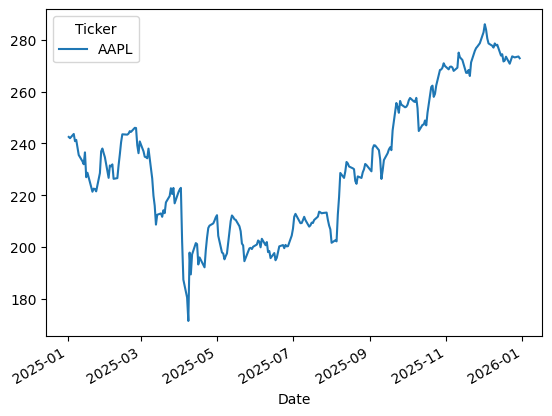

In [5]:

# Import the plotting library
import matplotlib.pyplot as plt
%matplotlib inline

# Plot the close price of the AAPL
data['Close'].plot()
plt.show()

## 讀取/儲存 Taiwan 歷史股票資訊

[*********************100%***********************]  1 of 1 completed


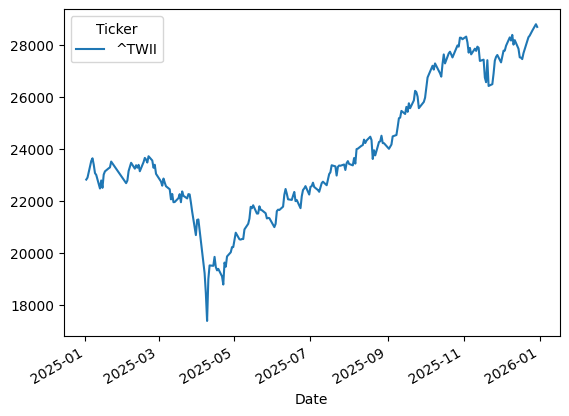

In [6]:
# Get the data of Taiwan for year of 2025

stockdata_TW = yf.download('^TWII','2025-01-01','2025-12-31')

# Plot the close price of Taiwan stock in year of 2025
stockdata_TW['Close'].plot()
plt.show()

In [7]:
# 今年下載的資料變成兩欄 -> 所以準備移除第二欄
stockdata_TW.head()

Price,Close,High,Low,Open,Volume
Ticker,^TWII,^TWII,^TWII,^TWII,^TWII
Date,,,,,
2025-01-02,22832.060547,23038.080078,22713.630859,22975.710938,3148600
2025-01-03,22908.300781,23092.070312,22905.400391,23018.560547,2828200
2025-01-06,23547.710938,23553.289062,23131.789062,23131.789062,2957500
2025-01-07,23651.269531,23943.949219,23651.269531,23824.720703,3207900
2025-01-08,23407.330078,23671.279297,23388.630859,23522.289062,2606700


##### 儲存 台灣2025年的歷史股票資訊

In [9]:
stockdata_TW.to_csv('data_New/data_TW_2025.csv')

In [30]:
stockdata_TW

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,22832.060547,23038.080078,22713.630859,22975.710938,3148600
2025-01-03,22908.300781,23092.070312,22905.400391,23018.560547,2828200
2025-01-06,23547.710938,23553.289062,23131.789062,23131.789062,2957500
2025-01-07,23651.269531,23943.949219,23651.269531,23824.720703,3207900
2025-01-08,23407.330078,23671.279297,23388.630859,23522.289062,2606700
...,...,...,...,...,...
2025-12-23,28310.470703,28350.369141,28212.839844,28253.140625,4559700
2025-12-24,28371.980469,28486.380859,28280.589844,28383.609375,4612900
2025-12-26,28556.019531,28590.910156,28404.339844,28443.480469,4511200


## 儲存 台灣及其他不同國家歷史股票資訊

In [ ]:
indices = ['^TWII','^AORD', '^AXJO', '^BFX', '^BSESN', '^BUK100P', '^BVSP', '^DJI', '^FCHI', '^GDAXI',
           '^GSPC', '^GSPTSE', '^HSI', '^JKSE', '^KS11', '^MXX', '^N225', '^NYA', '^NZ50',
           '^RUT', '^STOXX50E', '^TA125.TA', '^XAX', '000001.SS', 'IMOEX.ME']

for symbol in indices:
    df = yf.download(symbol, start='2025-01-01', end='2025-12-31')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
# should extend every empyt day stock data here...... (Try yourself)
    df.to_csv(f'data_New/{symbol}.csv')


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [17]:
area = pd.DataFrame({
    'Area': [
        'Taiwan',
        'Australia',
        'Australia',
        'Japan',
        'NewZealand',
        'UnitedStates',
        'UnitedStates',
        'Germany',
        'France',
        'HongKong',
        'SouthKorea',
        'Indonesia',
        'India',
        'Brazil',
        'Canada',
        'Mexico',
        'UnitedKingdom',
        'Europe',
        'Israel',
        'China',
        'Russia',
        'Belgium'
    ],
    'Code': [
        '^TWII',
        '^AORD',
        '^AXJO',
        '^N225',
        '^NZ50',
        '^DJI',
        '^GSPC',
        '^GDAXI',
        '^FCHI',
        '^HSI',
        '^KS11',
        '^JKSE',
        '^BSESN',
        '^BVSP',
        '^GSPTSE',
        '^MXX',
        '^BUK100P',
        '^STOXX50E',
        '^TA125.TA',
        '000001.SS',
        'IMOEX.ME',
        '^BFX'
    ]
})

area.to_csv('area.csv', index=False)

### 讀入股票代碼對應的地區資料並根據需要分組

In [18]:
# 將股票代碼對應的地區資料讀入
area = pd.read_csv('data_New/area.csv')
area

,Area,Code
0,Taiwan,^TWII
1,Australia,^AORD
2,Australia,^AXJO
3,NewZealand,^NZ50
4,Japan,^N225
5,Belgium,^BFX
6,India,^BSESN
7,UK,^BUK100P
8,Brazil,^BVSP
9,USA,^DJI


In [19]:
# 將股市代號分為:
# 1. 收盤時間同一日，但是比台灣收盤時間稍早的股市代號(earlier_stocks)，例如澳洲、紐西蘭、日本等
# 2. 收盤時間較台灣晚的股市代號(later_stocks), 例如歐洲及美國等國家
#    如果是因為收盤時間比台灣較晚,若要使用這些股市來進行預測,則需使用相對前一日的收盤資料進行當日的預測分析
earlier_taiwan_contries = ['Australia', 'NewZealand', 'Japan']  # 收盤時間同一日但稍早於台灣的國家
taiwan_stock = '^TWII'  # 台灣股市代號(TSEC weighted index)
earlier_stocks = list(
    area[area['Area'].isin(earlier_taiwan_contries)]['Code'])
later_stocks = list(
    area[~area['Area'].isin(earlier_taiwan_contries)]['Code'])
later_stocks.remove(taiwan_stock)

print(f'Taiwan: {taiwan_stock}')
print(f'Closing time on the same day but earlier than Taiwan: {earlier_stocks}')
print(f'Closing time Later than Taiwan: {later_stocks}')

Taiwan: ^TWII
Closing time on the same day but earlier than Taiwan: ['^AORD', '^AXJO', '^NZ50', '^N225']
Closing time Later than Taiwan: ['^BFX', '^BSESN', '^BUK100P', '^BVSP', '^DJI', '^FCHI', '^GDAXI', '^GSPC', '^GSPTSE', '^HSI', '^JKSE', '^KS11', '^MXX', '^NYA', '^RUT', '^STOXX50E', '^TA125.TA', '^XAX', '000001.SS', 'IMOEX.ME']


### 撰寫讀取股市資料的函式

In [20]:
yf.Ticker('^N225')

yfinance.Ticker object <^N225>

In [21]:
yf.Ticker('^DJI')

yfinance.Ticker object <^DJI>

In [26]:
yf.Ticker('^DJI').history(
    start='2025-01-01',
    end='2025-12-31'
)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-02 00:00:00-05:00,42660.089844,42905.089844,42174.800781,42392.269531,459850000,0.0,0.0
2025-01-03 00:00:00-05:00,42495.761719,42782.761719,42436.921875,42732.128906,455810000,0.0,0.0
2025-01-06 00:00:00-05:00,42835.519531,43115.308594,42611.160156,42706.558594,557040000,0.0,0.0
2025-01-07 00:00:00-05:00,42809.710938,42931.539062,42380.750000,42528.359375,621630000,0.0,0.0
2025-01-08 00:00:00-05:00,42542.101562,42656.218750,42327.789062,42635.199219,463430000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-23 00:00:00-05:00,48320.589844,48527.500000,48254.308594,48442.410156,418920000,0.0,0.0
2025-12-24 00:00:00-05:00,48424.710938,48771.320312,48386.589844,48731.160156,206740000,0.0,0.0
2025-12-26 00:00:00-05:00,48712.468750,48782.000000,48589.070312,48710.968750,288770000,0.0,0.0


In [27]:
yf.Ticker('^DJI').history(
    start='2025-01-01',
    end='2025-12-31'
).count()

Open            249
High            249
Low             249
Close           249
Volume          249
Dividends       249
Stock Splits    249
dtype: int64

### 將所有股市資料讀入並合併

In [ ]:
import pandas as pd
import yfinance as yf

start_date = '2025-01-01'
end_date = '2026-01-01'   # 要包含 2025-12-31, +1天


def read_stock_close(code, start=start_date, end=end_date):
    """
    讀取單一股市指數的收盤價，回傳格式：
    Date | code
    """
    df = yf.Ticker(code).history(start=start, end=end)

    if df.empty:
        print(f'No data: {code}')
        return None

    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df = df.reset_index()

    # 只保留日期，不保留時間
    df['Date'] = pd.to_datetime(df['Date']).dt.normalize()

    # 只取收盤價
    df = df[['Date', 'Close']].copy()
    df = df.rename(columns={'Close': code})

    return df


# 讀入台灣股市資料
stock = read_stock_close(taiwan_stock)

# 用台灣股市交易日作為主表
stock = stock.sort_values('Date').reset_index(drop=True)

for code in earlier_stocks + later_stocks:
    print(code)

    single_stock = read_stock_close(code)

    if single_stock is None:
        continue

    single_stock = single_stock.sort_values('Date').reset_index(drop=True)

    if code in earlier_stocks:
        # 收盤時間同一日但早於台灣：
        # 可以用同一天的收盤價
        stock = pd.merge_asof(
            stock,
            single_stock,
            on='Date',
            direction='backward',
            allow_exact_matches=True
        )

    elif code in later_stocks:
        # 收盤時間晚於台灣：
        # 台灣當日不能用該市場同日收盤價，因此使用「前一個可取得交易日」的收盤價
        stock = pd.merge_asof(
            stock,
            single_stock,
            on='Date',
            direction='backward',
            allow_exact_matches=False
        )

# 去除有空值的紀錄
stock.dropna(inplace=True)

# 將收盤價欄位轉為數值
stock.iloc[:, 1:] = stock.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

stock = stock.dropna().reset_index(drop=True)

stock.head(10)

^AORD
^AXJO
^NZ50
^N225
^BFX
^BSESN
^BUK100P
^BVSP
^DJI
^FCHI
^GDAXI
^GSPC
^GSPTSE
^HSI
^JKSE
^KS11
^MXX
^NYA
^RUT
^STOXX50E
^TA125.TA
^XAX
000001.SS
IMOEX.ME


$IMOEX.ME: possibly delisted; no price data found  (1d 2025-01-01 -> 2026-01-01)


No data: IMOEX.ME


,Date,^TWII,^AORD,^AXJO,^NZ50,^N225,^BFX,^BSESN,^BUK100P,^BVSP,...,^HSI,^JKSE,^KS11,^MXX,^NYA,^RUT,^STOXX50E,^TA125.TA,^XAX,000001.SS
0,2025-01-06,23547.710938,8545.700195,8288.500000,13047.230469,39307.050781,4259.129883,79223.109375,824.669983,118533.0,...,19760.269531,7164.429199,2441.919922,48957.238281,19254.289062,2268.469971,4871.450195,2452.889893,4759.529785,3211.429932
1,2025-01-07,23651.269531,8542.900391,8285.099609,13013.519531,40083.300781,4284.410156,77964.992188,826.320007,120022.0,...,19688.289062,7080.474121,2488.639893,49493.558594,19261.419922,2266.649902,4986.640137,2500.969971,4786.009766,3206.923096
2,2025-01-08,23407.330078,8599.400391,8349.099609,13011.910156,39981.058594,4300.560059,78199.109375,825.840027,121163.0,...,19447.580078,7083.284180,2492.100098,50085.500000,19213.880859,2249.800049,5011.819824,2500.729980,4879.129883,3229.644043
3,2025-01-09,23081.130859,8577.799805,8329.200195,12940.309570,39605.089844,4299.279785,78148.492188,826.140015,119625.0,...,19279.839844,7080.352051,2521.050049,49634.261719,19240.740234,2238.959961,4996.390137,2480.620117,4902.089844,3230.167969
4,2025-01-10,23011.859375,8543.700195,8294.099609,12895.980469,39190.398438,4301.839844,77620.210938,832.809998,119781.0,...,19240.890625,7064.587891,2521.899902,49807.960938,19240.740234,2238.959961,5017.910156,2488.360107,4902.089844,3211.393066
5,2025-01-13,22488.330078,8431.900391,8191.899902,12808.830078,39190.398438,4233.930176,77378.906250,826.799988,118856.0,...,19064.289062,7088.866211,2515.780029,49596.699219,18963.009766,2189.229980,4977.259766,2488.360107,4914.859863,3168.523926
6,2025-01-14,22797.519531,8471.799805,8231.000000,12884.379883,38474.300781,4199.029785,76330.007812,824.630005,119007.0,...,18874.140625,7016.878906,2489.560059,49829.968750,19047.330078,2194.399902,4954.209961,2490.870117,4870.589844,3160.754883
7,2025-01-15,22514.570312,8456.799805,8213.299805,12941.750000,38444.578125,4200.649902,76499.632812,822.380005,119299.0,...,19219.779297,6956.665039,2497.399902,49844.000000,19176.650391,2219.239990,4980.470215,2526.659912,4911.910156,3240.939941
8,2025-01-16,23025.099609,8569.099609,8327.000000,13004.219727,38572.601562,4234.750000,76724.078125,832.510010,122650.0,...,19286.070312,7079.562012,2496.810059,50242.839844,19422.710938,2263.290039,5032.310059,2558.580078,4974.209961,3227.116943
9,2025-01-17,23148.080078,8557.400391,8310.400391,13130.429688,38451.460938,4244.479980,77042.820312,840.510010,121234.0,...,19522.890625,7107.519043,2527.489990,49948.148438,19548.630859,2266.790039,5106.930176,2567.070068,4990.290039,3236.031982


### 查看整理後的股市概況

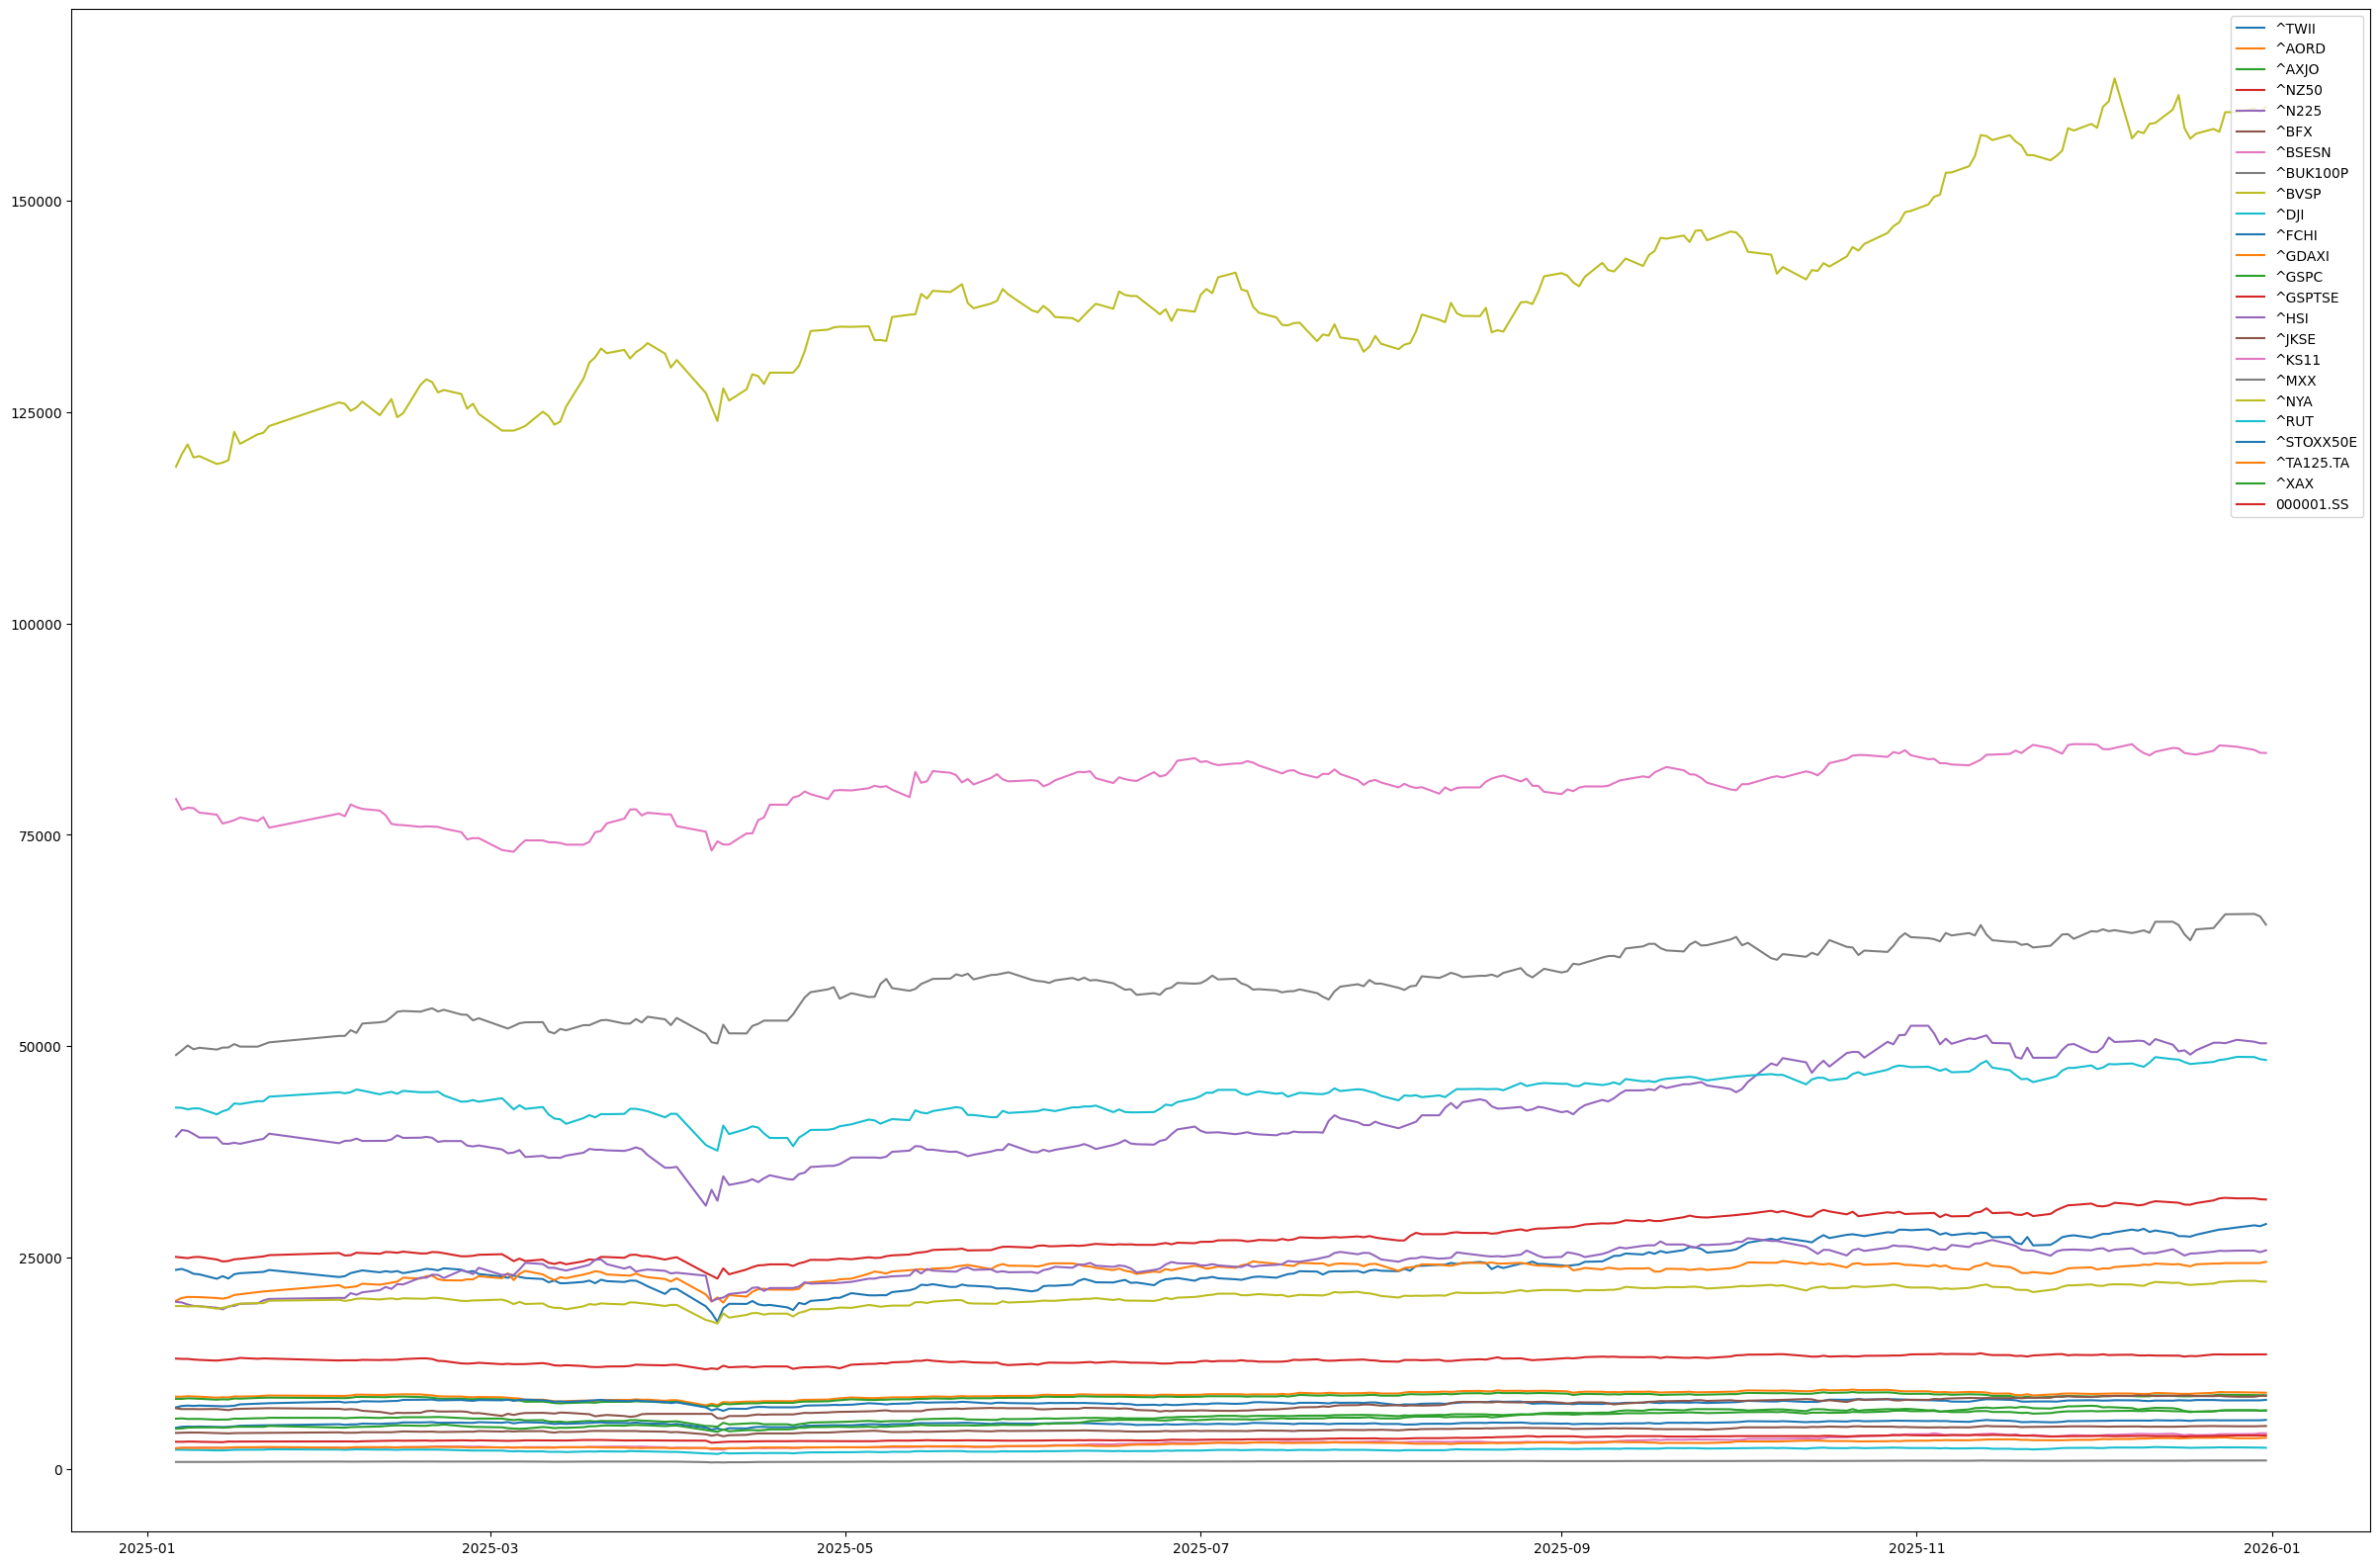

In [30]:
# 俄羅斯莫斯科交易所股票去年沒資料 先移掉

if 'IMOEX.ME' in earlier_stocks:
    earlier_stocks.remove('IMOEX.ME')

if 'IMOEX.ME' in later_stocks:
    later_stocks.remove('IMOEX.ME')

plt.figure(figsize=(30, 20))
plt.plot(stock['Date'], stock[taiwan_stock], label=taiwan_stock)
for code in (earlier_stocks+later_stocks):
    plt.plot(stock['Date'], stock[code], label=code)
plt.legend()

In [31]:
# 開始與結束時間
min(stock["Date"]).date(), max(stock["Date"]).date()

(datetime.date(2025, 1, 6), datetime.date(2025, 12, 31))

In [32]:
print(stock.iloc[:, 1:])

            ^TWII        ^AORD        ^AXJO         ^NZ50         ^N225  \
0    23547.710938  8545.700195  8288.500000  13047.230469  39307.050781   
1    23651.269531  8542.900391  8285.099609  13013.519531  40083.300781   
2    23407.330078  8599.400391  8349.099609  13011.910156  39981.058594   
3    23081.130859  8577.799805  8329.200195  12940.309570  39605.089844   
4    23011.859375  8543.700195  8294.099609  12895.980469  39190.398438   
..            ...          ...          ...           ...           ...   
236  28371.980469  9069.000000  8762.700195  13529.059570  50344.101562   
237  28556.019531  9069.000000  8762.700195  13529.059570  50750.390625   
238  28810.890625  9032.000000  8725.700195  13540.910156  50526.921875   
239  28707.130859  9022.400391  8717.099609  13548.969727  50339.480469   
240  28963.599609  9018.799805  8714.299805  13548.419922  50339.480469   

            ^BFX        ^BSESN    ^BUK100P     ^BVSP          ^DJI  ...  \
0    4259.129883  79223.

<Axes: >

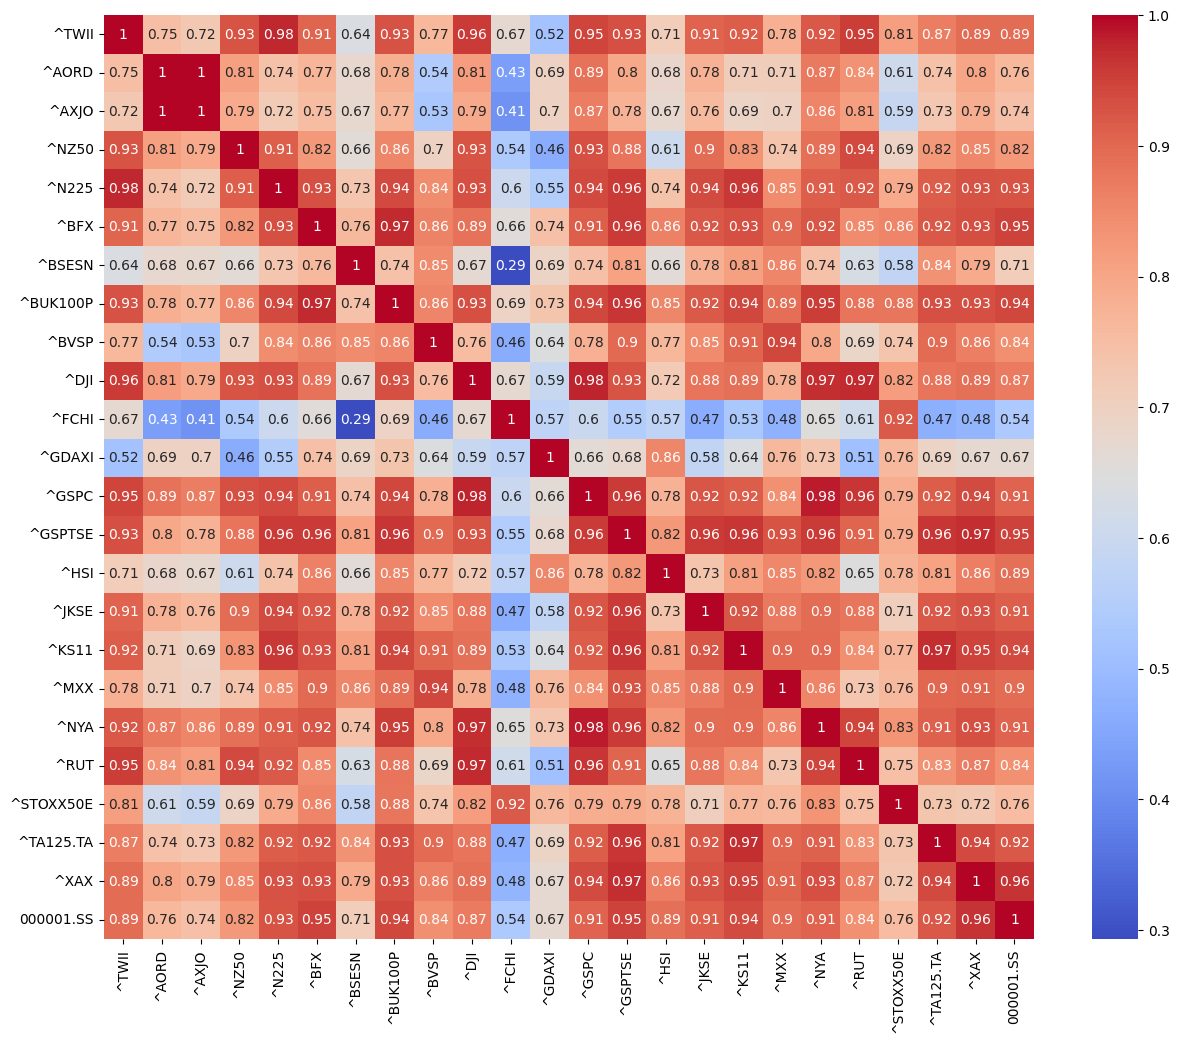

In [33]:
# 各國股市之間的相關度熱圖
import seaborn as sns
corr = stock.iloc[:, 1:].corr(method='pearson').round(3)

plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm', annot = True, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

## 4. 利用清理後的資料訓練模型

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

### 分為訓練資料與測試資料

In [35]:
train, test = train_test_split(stock, random_state=10, train_size=0.8)
x_cols = earlier_stocks + later_stocks
train_x = train[x_cols]
train_y = train[taiwan_stock]

In [36]:
x_cols

['^AORD',
 '^AXJO',
 '^NZ50',
 '^N225',
 '^BFX',
 '^BSESN',
 '^BUK100P',
 '^BVSP',
 '^DJI',
 '^FCHI',
 '^GDAXI',
 '^GSPC',
 '^GSPTSE',
 '^HSI',
 '^JKSE',
 '^KS11',
 '^MXX',
 '^NYA',
 '^RUT',
 '^STOXX50E',
 '^TA125.TA',
 '^XAX',
 '000001.SS']

In [37]:
train_x.head()

,^AORD,^AXJO,^NZ50,^N225,^BFX,^BSESN,^BUK100P,^BVSP,^DJI,^FCHI,...,^HSI,^JKSE,^KS11,^MXX,^NYA,^RUT,^STOXX50E,^TA125.TA,^XAX,000001.SS
174,9137.799805,8845.900391,13136.540039,45493.660156,4707.560059,82159.968750,924.940002,145109.0,46381.539062,7830.109863,...,26344.140625,8040.039062,3468.649902,62004.109375,21542.470703,2463.340088,5442.049805,3074.179932,7028.500000,3828.575928
103,8775.000000,8548.400391,12690.129883,38311.328125,4476.209961,81118.601562,881.030029,137213.0,42197.789062,7684.680176,...,23892.560547,7166.064941,2894.620117,57438.570312,19981.070312,2100.510010,5290.470215,2705.879883,5805.339844,3376.996094
147,9212.099609,8938.599609,12889.379883,43378.308594,4779.129883,80597.656250,919.090027,136356.0,44911.261719,7870.339844,...,25519.320312,7931.250977,3225.659912,58167.269531,20808.429688,2299.080078,5434.700195,3032.290039,6142.669922,3666.443115
168,9120.900391,8853.000000,13208.309570,44768.121094,4775.680176,81904.703125,931.010010,142272.0,45834.218750,7825.240234,...,26388.160156,7854.060059,3395.540039,61798.941406,21374.320312,2397.060059,5390.709961,3162.560059,6877.740234,3870.597900
129,8941.500000,8677.200195,12833.740234,39774.921875,4554.080078,82200.343750,898.500000,134167.0,44323.070312,7798.220215,...,24994.140625,7398.191895,3210.810059,55841.300781,20514.470703,2231.129883,5342.979980,3110.770020,5971.029785,3559.791016


### 訓練決策樹回歸模型

In [38]:
train_y.head()

174    26247.369141
103    22049.900391
147    24334.480469
168    25357.160156
129    22987.919922
Name: ^TWII, dtype: float64

In [39]:
clf = DecisionTreeRegressor()
clf.fit(train_x, train_y)

DecisionTreeRegressor()

In [40]:
clf.get_depth(), clf.get_n_leaves()

(17, 192)

### 驗證預測結果

In [41]:
# 因為前面使用train_test_split函式會將日期順序打亂, 這裡重新排序以便繪圖
test.sort_values('Date', inplace=True)
test_x = test[x_cols]
test_y = test[taiwan_stock]
predict_y = clf.predict(test_x)

In [42]:
test_x.head()

,^AORD,^AXJO,^NZ50,^N225,^BFX,^BSESN,^BUK100P,^BVSP,^DJI,^FCHI,...,^HSI,^JKSE,^KS11,^MXX,^NYA,^RUT,^STOXX50E,^TA125.TA,^XAX,000001.SS
5,8431.900391,8191.899902,12808.830078,39190.398438,4233.930176,77378.906250,826.799988,118856.0,41938.449219,7431.040039,...,19064.289062,7088.866211,2515.780029,49596.699219,18963.009766,2189.229980,4977.259766,2488.360107,4914.859863,3168.523926
19,8751.599609,8484.000000,12903.250000,38801.171875,4348.970215,77311.796875,878.880005,125572.0,44470.410156,8006.220215,...,21521.980469,6648.142090,2521.270020,52928.121094,20117.880859,2287.939941,5358.299805,2588.350098,5079.399902,3322.169922
20,8799.599609,8535.299805,12893.679688,38963.699219,4338.209961,76293.601562,879.419983,126522.0,44593.648438,8028.899902,...,21294.859375,6531.990234,2539.050049,53451.640625,20168.210938,2275.699951,5390.910156,2568.449951,5133.839844,3318.056885
24,8756.700195,8481.000000,13074.379883,39270.398438,4402.310059,75996.859375,879.700012,128869.0,44546.078125,8189.129883,...,22616.230469,6830.881836,2610.419922,54291.640625,20130.490234,2279.979980,5519.830078,2571.209961,5100.709961,3355.830078
26,8601.700195,8322.799805,12780.879883,38678.039062,4370.160156,75939.179688,873.289978,127309.0,44627.589844,8110.540039,...,22944.240234,6794.868164,2671.520020,54096.511719,20228.199219,2282.459961,5461.169922,2602.629883,5181.879883,3351.539062


In [43]:
test_y.head()

5     22488.330078
19    23384.050781
20    23289.750000
24    23666.109375
26    23487.460938
Name: ^TWII, dtype: float64

In [44]:
predict_y

array([23011.859375  , 23152.609375  , 23266.8203125 , 23505.33007812,
       23565.31054688, 22871.90039062, 22278.359375  , 20695.90039062,
       19468.        , 19395.02929688, 19395.02929688, 19395.02929688,
       19395.02929688, 20232.63085938, 20232.63085938, 20232.63085938,
       20532.99023438, 21330.140625  , 22242.140625  , 21660.66015625,
       22211.58984375, 22188.75976562, 22553.72070312, 22553.72070312,
       22553.72070312, 22553.72070312, 23316.59960938, 23542.51953125,
       23373.73046875, 23447.359375  , 24370.01953125, 24519.90039062,
       24071.73046875, 23962.13085938, 24494.58007812, 25580.3203125 ,
       26023.84960938, 26378.390625  , 26378.390625  , 26378.390625  ,
       27275.7109375 , 26378.390625  , 28116.56054688, 28116.56054688,
       27784.94921875, 27947.08984375, 26434.93945312, 28198.01953125,
       27564.26953125])

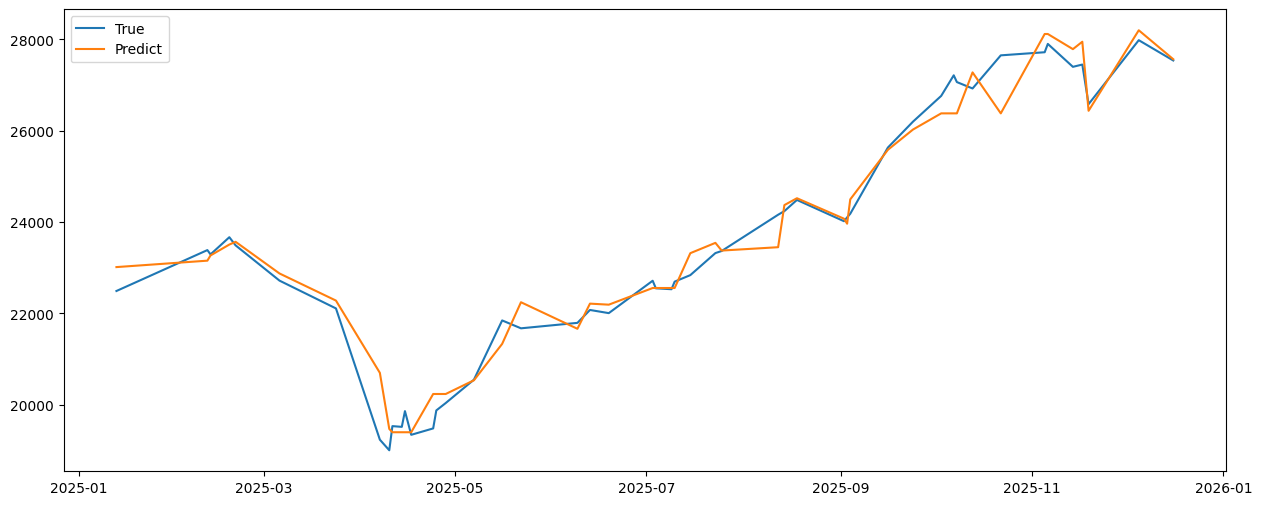

In [45]:
# 預測結果於實際情況差異
plt.figure(figsize=(15, 6))
plt.plot(test['Date'], test_y, label='True')
plt.plot(test['Date'], predict_y, label='Predict')
plt.legend()

In [46]:
# 預測結果與實際情況的平均差
def get_mean_square_error(y1s, y2s):
    return sum((y1-y2)**2 for y1, y2 in zip(y1s, y2s)) / len(y1s)
mse = get_mean_square_error(test_y, predict_y)
mse**0.5

432.1535461780122

In [47]:
taiwan_stock

'^TWII'

## 5. 選擇高相關的股市資料重新訓練

In [48]:
corr = stock.iloc[:, 1:].corr(method='pearson').round(3)

<Axes: >

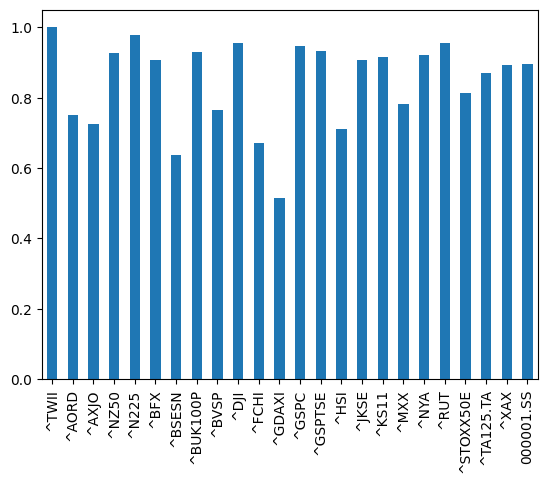

In [49]:
# 查看相關係數的分布狀況
corr = abs(corr[taiwan_stock])
corr.plot.bar()

In [50]:
train_x

,^AORD,^AXJO,^NZ50,^N225,^BFX,^BSESN,^BUK100P,^BVSP,^DJI,^FCHI,...,^HSI,^JKSE,^KS11,^MXX,^NYA,^RUT,^STOXX50E,^TA125.TA,^XAX,000001.SS
174,9137.799805,8845.900391,13136.540039,45493.660156,4707.560059,82159.968750,924.940002,145109.0,46381.539062,7830.109863,...,26344.140625,8040.039062,3468.649902,62004.109375,21542.470703,2463.340088,5442.049805,3074.179932,7028.500000,3828.575928
103,8775.000000,8548.400391,12690.129883,38311.328125,4476.209961,81118.601562,881.030029,137213.0,42197.789062,7684.680176,...,23892.560547,7166.064941,2894.620117,57438.570312,19981.070312,2100.510010,5290.470215,2705.879883,5805.339844,3376.996094
147,9212.099609,8938.599609,12889.379883,43378.308594,4779.129883,80597.656250,919.090027,136356.0,44911.261719,7870.339844,...,25519.320312,7931.250977,3225.659912,58167.269531,20808.429688,2299.080078,5434.700195,3032.290039,6142.669922,3666.443115
168,9120.900391,8853.000000,13208.309570,44768.121094,4775.680176,81904.703125,931.010010,142272.0,45834.218750,7825.240234,...,26388.160156,7854.060059,3395.540039,61798.941406,21374.320312,2397.060059,5390.709961,3162.560059,6877.740234,3870.597900
129,8941.500000,8677.200195,12833.740234,39774.921875,4554.080078,82200.343750,898.500000,134167.0,44323.070312,7798.220215,...,24994.140625,7398.191895,3210.810059,55841.300781,20514.470703,2231.129883,5342.979980,3110.770020,5971.029785,3559.791016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,8021.899902,7819.100098,12118.990234,34730.281250,4197.649902,78553.203125,824.580017,129650.0,39142.230469,7285.859863,...,21395.140625,6438.269043,2470.409912,53018.570312,18367.119141,1880.619995,4935.339844,2536.429932,4675.850098,3280.341064
15,8683.400391,8416.900391,12844.589844,38831.480469,4277.180176,78583.812500,858.390015,125147.0,44556.039062,7906.399902,...,20789.960938,7073.458984,2481.689941,51889.750000,19964.609375,2290.209961,5264.589844,2537.979980,4946.479980,3250.601074
228,8983.299805,8697.299805,13406.910156,50836.550781,5000.500000,84818.132812,971.609985,159189.0,48704.011719,8085.759766,...,25530.509766,8620.481445,4110.620117,64712.070312,22114.419922,2590.610107,5753.959961,3648.100098,7228.609863,3873.318115
125,8816.400391,8561.799805,12754.589844,39663.398438,4498.029785,82570.906250,892.750000,135250.0,44023.289062,7766.209961,...,24590.119141,7140.474121,3215.280029,56482.910156,20374.380859,2205.050049,5354.169922,3073.620117,5936.779785,3504.999023


['^TWII', '^NZ50', '^N225', '^BFX', '^BUK100P', '^DJI', '^GSPC', '^GSPTSE', '^JKSE', '^KS11', '^NYA', '^RUT']
['^NZ50', '^N225', '^BFX', '^BUK100P', '^DJI', '^GSPC', '^GSPTSE', '^JKSE', '^KS11', '^NYA', '^RUT']


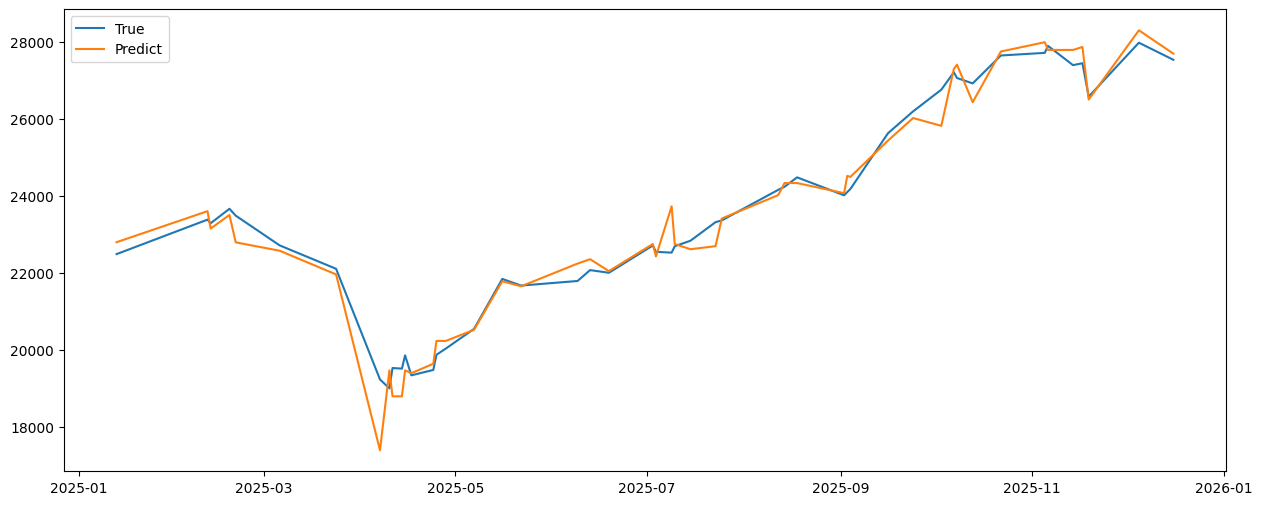

In [51]:
threshold = 0.90
x_cols = list(corr[corr>threshold].index)
print(x_cols)
x_cols.remove('^TWII')
print(x_cols)
train_x = train[x_cols]
train_y = train[taiwan_stock]
clf = DecisionTreeRegressor()
clf.fit(train_x, train_y)
test_x = test[x_cols]
test_y = test[taiwan_stock]
predict_y = clf.predict(test_x)

plt.figure(figsize=(15, 6))
plt.plot(test['Date'], test_y, label='True')
plt.plot(test['Date'], predict_y, label='Predict')
plt.legend()

In [52]:
mse = get_mean_square_error(test_y, predict_y)
mse**0.5

454.85693749526195

['^TWII', '^NZ50', '^N225', '^BFX', '^BUK100P', '^DJI', '^GSPC', '^GSPTSE', '^JKSE', '^KS11', '^NYA', '^RUT', '^STOXX50E', '^TA125.TA', '^XAX', '000001.SS']
['^NZ50', '^N225', '^BFX', '^BUK100P', '^DJI', '^GSPC', '^GSPTSE', '^JKSE', '^KS11', '^NYA', '^RUT', '^STOXX50E', '^TA125.TA', '^XAX', '000001.SS']


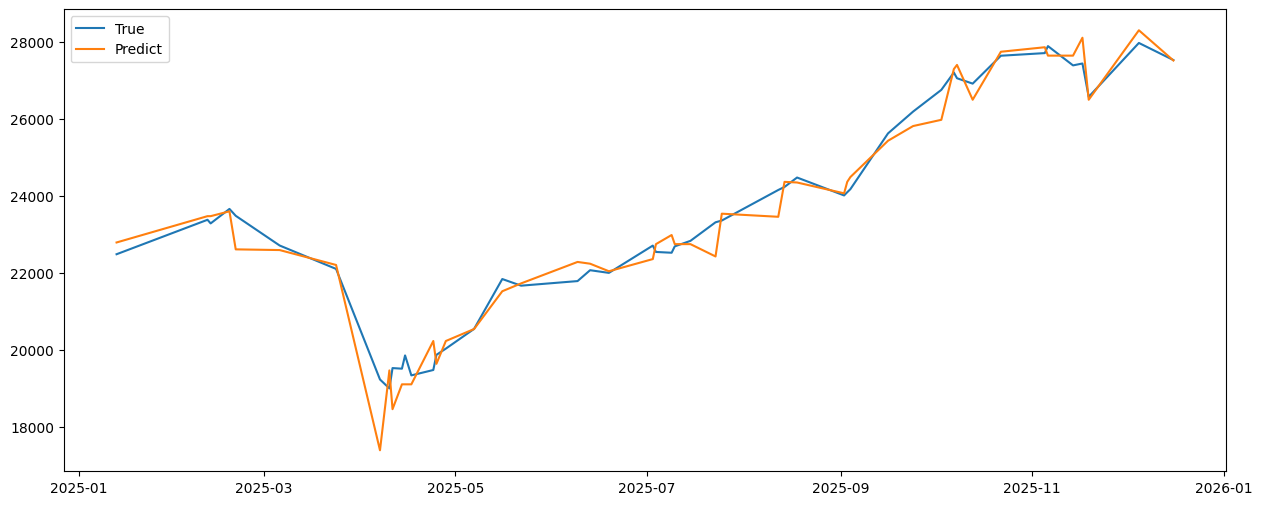

In [53]:
threshold = 0.8
x_cols = list(corr[corr>threshold].index)
print(x_cols)
x_cols.remove('^TWII')
print(x_cols)
train_x = train[x_cols]
train_y = train[taiwan_stock]
clf = DecisionTreeRegressor()
clf.fit(train_x, train_y)
test_x = test[x_cols]
test_y = test[taiwan_stock]
predict_y = clf.predict(test_x)

plt.figure(figsize=(15, 6))
plt.plot(test['Date'], test_y, label='True')
plt.plot(test['Date'], predict_y, label='Predict')
plt.legend()

In [54]:
mse = get_mean_square_error(test_y, predict_y)
mse**0.5

478.4507796855993